In [1]:
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import random_split

from torchvision import datasets
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [2]:
batch_size = 128

Loads the test_val_datset, and the test_dataset. This will take a couple of minutes to load

In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

training_data = datasets.CIFAR10(
    root= "data", 
    train = True,
    download=True,
    transform=transform
)

testing_data = datasets.CIFAR10(
    root= "data", 
    train = False,
    download=True,
    transform=transform
)



In [17]:
train_val_amt = int(len(training_data) * 0.75)
validation_set = int(len(training_data) - train_val_amt)

print(train_val_amt, validation_set)

train_dataset, validation_dataset = random_split(training_data, [train_val_amt, validation_set], generator=torch.Generator().manual_seed(1234))

37500 12500


In [18]:
train_data_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
testing_data_loader = DataLoader(testing_data, batch_size = batch_size, shuffle = True)

Prints the dataset numbers and percentage of training and validation data.

In [26]:
print(f"Training Data Total: {len(train_dataset)}, {len(train_dataset) / (len(train_dataset) + len(validation_dataset))}")
print(f"Validation Data Total: {len(validation_dataset)}, {len(validation_dataset) / (len(train_dataset) + len(validation_dataset))}")
print(f"Testing Data total:", len(testing_data))


Training Data Total: 37500, 0.75
Validation Data Total: 12500, 0.25
Testing Data total: 10000


tensor([[[0.1490, 0.0902, 0.0667],
         [0.1569, 0.0980, 0.0745],
         [0.1569, 0.0980, 0.0745],
         ...,
         [0.4039, 0.3216, 0.2549],
         [0.3686, 0.2745, 0.1882],
         [0.4431, 0.3608, 0.2902]],

        [[0.1373, 0.0824, 0.0667],
         [0.1451, 0.0902, 0.0784],
         [0.1569, 0.0980, 0.0784],
         ...,
         [0.2863, 0.2039, 0.1255],
         [0.3137, 0.2118, 0.1216],
         [0.4157, 0.3373, 0.2588]],

        [[0.1373, 0.0941, 0.0706],
         [0.1333, 0.0902, 0.0627],
         [0.1451, 0.0941, 0.0706],
         ...,
         [0.2706, 0.1804, 0.0941],
         [0.3333, 0.2275, 0.1373],
         [0.4000, 0.3176, 0.2510]],

        ...,

        [[0.8745, 0.7529, 0.6510],
         [0.7255, 0.6235, 0.5255],
         [0.5255, 0.4275, 0.3333],
         ...,
         [0.7255, 0.6784, 0.6275],
         [0.7294, 0.6902, 0.6471],
         [0.7451, 0.7020, 0.6627]],

        [[0.7882, 0.6667, 0.5647],
         [0.7882, 0.6824, 0.5882],
         [0.

Text(0.5, 1.0, 'Cat')

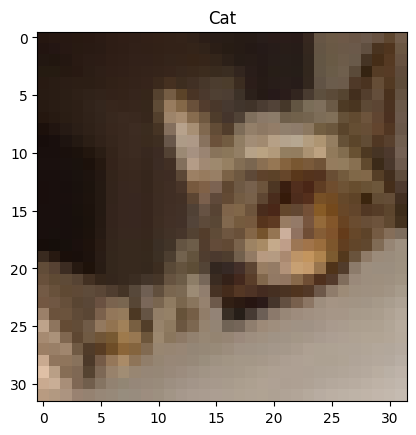

In [48]:
classes = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"]
training_iter = iter(train_data_loader)

data_obj, label = next(training_iter)
data_obj = data_obj[0]
data_obj = data_obj * 0.5 + 0.5
label = label[0]
data_obj = data_obj.permute(1, 2, 0)
print(data_obj, label)
plt.imshow(data_obj)
plt.title(f"{classes[label]}")